In [10]:
from pathlib import Path

import torch
import numpy as np
import matplotlib.pyplot as plt


In [127]:
ATTN_DIR = Path("attn")
LAYER = 1
HEAD = 0

# FFT input ranges. End is exclusive: 0:69 means frames 0-68; None means through the last frame.
FFT_RANGES = [
    {"label": "0-68", "start": 0, "end": 63},
    {"label": "0-71", "start": 0, "end": None},
]

# Period display range in frames/cycle. Zero frequency is excluded from period plots.
PERIOD_MIN = 2.0
PERIOD_MAX = None

REMOVE_DC = True
APPLY_WINDOW = True


In [128]:
attn_path = ATTN_DIR / f"layer{LAYER}.pt"
payload = torch.load(attn_path, map_location="cpu", weights_only=False)

per_head = payload["last_frame_attention_per_head"]
if per_head.ndim != 2:
    raise ValueError(f"Expected per-head attention to be 2D, got shape {tuple(per_head.shape)}")
if not 0 <= HEAD < per_head.shape[0]:
    raise IndexError(f"HEAD={HEAD} is out of range for {per_head.shape[0]} heads")

attention = per_head[HEAD].detach().cpu().float().numpy()
if attention.ndim != 1:
    raise ValueError(f"Expected selected head attention to be 1D, got shape {attention.shape}")

num_frames = attention.shape[0]
frame_idx = np.arange(num_frames)
print(f"Loaded {attn_path}: layer={LAYER}, head={HEAD}, frames={num_frames}")


Loaded attn/layer1.pt: layer=1, head=0, frames=72


In [129]:
def normalize_range(start, end, size):
    start = 0 if start is None else start
    end = size if end is None else end
    start_norm = start if start >= 0 else size + start
    end_norm = end if end >= 0 else size + end
    if start_norm < 0 or end_norm > size or start_norm >= end_norm:
        raise ValueError(f"Invalid FFT range {start}:{end} for {size} frames")
    return start, end, start_norm, end_norm


def period_spectrum(sequence):
    if sequence.ndim != 1 or sequence.size < 2:
        raise ValueError(f"FFT input must be 1D with at least 2 frames, got shape {sequence.shape}")

    signal = sequence.astype(np.float64, copy=True)
    if REMOVE_DC:
        signal = signal - signal.mean()
    if APPLY_WINDOW:
        signal = signal * np.hanning(signal.size)

    freq = np.fft.rfftfreq(signal.size, d=1.0)
    amplitude = np.abs(np.fft.rfft(signal))
    nonzero_mask = freq > 0
    if not np.any(nonzero_mask):
        raise ValueError("FFT produced no nonzero frequency bins")

    period = 1.0 / freq[nonzero_mask]
    period_amplitude = amplitude[nonzero_mask]
    order = np.argsort(period)
    period = period[order]
    period_amplitude = period_amplitude[order]

    display_mask = np.ones_like(period, dtype=bool)
    if PERIOD_MIN is not None:
        display_mask &= period >= PERIOD_MIN
    if PERIOD_MAX is not None:
        display_mask &= period <= PERIOD_MAX
    if not np.any(display_mask):
        raise ValueError(f"Period display range [{PERIOD_MIN}, {PERIOD_MAX}] contains no FFT bins")

    nonzero_indices = np.flatnonzero(nonzero_mask)
    dominant_idx = nonzero_indices[np.argmax(amplitude[nonzero_mask])]
    dominant_freq = freq[dominant_idx]
    dominant_period = 1.0 / dominant_freq
    dominant_amp = amplitude[dominant_idx]

    return {
        "period": period,
        "period_amplitude": period_amplitude,
        "display_mask": display_mask,
        "dominant_freq": dominant_freq,
        "dominant_period": dominant_period,
        "dominant_amp": dominant_amp,
        "signal_size": signal.size,
    }


results = []
for cfg in FFT_RANGES:
    start, end, start_norm, end_norm = normalize_range(cfg.get("start"), cfg.get("end"), num_frames)
    spectrum = period_spectrum(attention[start:end])
    result = {**cfg, **spectrum, "start_norm": start_norm, "end_norm": end_norm}
    results.append(result)

    inclusive_end = end_norm - 1
    print(
        f"{cfg['label']}: frames {start_norm}-{inclusive_end} ({spectrum['signal_size']} frames), "
        f"dominant period={spectrum['dominant_period']:.3f} frames, "
        f"dominant frequency={spectrum['dominant_freq']:.6f} cycles/frame, "
        f"amplitude={spectrum['dominant_amp']:.6g}"
    )


0-68: frames 0-62 (63 frames), dominant period=31.500 frames, dominant frequency=0.031746 cycles/frame, amplitude=14.2512
0-71: frames 0-71 (72 frames), dominant period=36.000 frames, dominant frequency=0.027778 cycles/frame, amplitude=15.7127


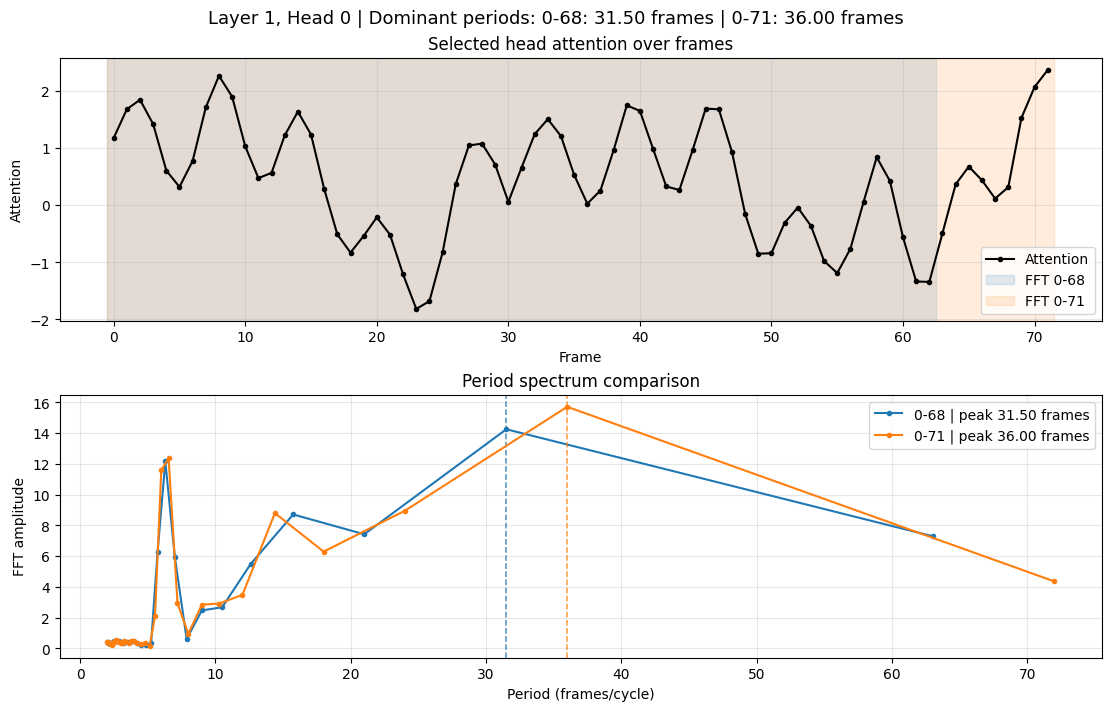

In [130]:
fig, (ax_time, ax_period) = plt.subplots(2, 1, figsize=(11, 7), constrained_layout=True)

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
ax_time.plot(frame_idx, attention, marker="o", linewidth=1.5, markersize=3, color="black", label="Attention")
for idx, result in enumerate(results):
    color = colors[idx % len(colors)]
    ax_time.axvspan(
        result["start_norm"] - 0.5,
        result["end_norm"] - 0.5,
        color=color,
        alpha=0.14,
        label=f"FFT {result['label']}",
    )
ax_time.set_xlabel("Frame")
ax_time.set_ylabel("Attention")
ax_time.set_title("Selected head attention over frames")
ax_time.grid(True, alpha=0.3)
ax_time.legend(loc="best")

for idx, result in enumerate(results):
    color = colors[idx % len(colors)]
    mask = result["display_mask"]
    ax_period.plot(
        result["period"][mask],
        result["period_amplitude"][mask],
        marker="o",
        linewidth=1.5,
        markersize=3,
        color=color,
        label=f"{result['label']} | peak {result['dominant_period']:.2f} frames",
    )
    dominant_visible = (
        np.isfinite(result["dominant_period"])
        and (PERIOD_MIN is None or result["dominant_period"] >= PERIOD_MIN)
        and (PERIOD_MAX is None or result["dominant_period"] <= PERIOD_MAX)
    )
    if dominant_visible:
        ax_period.axvline(result["dominant_period"], color=color, linestyle="--", linewidth=1.1, alpha=0.8)

ax_period.set_xlabel("Period (frames/cycle)")
ax_period.set_ylabel("FFT amplitude")
ax_period.set_title("Period spectrum comparison")
ax_period.grid(True, alpha=0.3)
ax_period.legend(loc="best")

summary = " | ".join(f"{r['label']}: {r['dominant_period']:.2f} frames" for r in results)
fig.suptitle(f"Layer {LAYER}, Head {HEAD} | Dominant periods: {summary}", fontsize=13)
plt.show()
